In [1]:
from ler import LeR
import numpy as np
import matplotlib.pyplot as plt

In [7]:
ler_cs_int = LeR(
    npool=6,
    interpolator_directory='../interpolator_json',
    # directory="../interpolator_json",
    # Strongly lensed lens redshift is a *prior/sampler*, not a lens_function.
    # Settings must go through lens_priors / lens_priors_params (see OpticalDepth setter for lens_redshift_sl).
    lens_functions=dict(
        cross_section='cross_section_epl_shear_njit'
    ),
    lens_priors=dict(
        lens_redshift_sl="lens_redshift_strongly_lensed_numerical",
    ),
    lens_priors_params=dict(
        lens_redshift_sl=dict(
            param_name="lens_redshift_sl",
            sampler_type="lens_redshift_strongly_lensed_numerical",
            lens_type="epl_shear_galaxy",
            integration_size=50000,
            use_multiprocessing=False,
            cross_section_epl_shear_interpolation=False,
        ),
    ),
)
# 5m 528.s


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/raylei

In [6]:
ler_cs_num = LeR(
    npool=6,
    interpolator_directory='../interpolator_json',
    # directory="../interpolator_json",
    # Strongly lensed lens redshift is a *prior/sampler*, not a lens_function.
    # Settings must go through lens_priors / lens_priors_params (see OpticalDepth setter for lens_redshift_sl).
    lens_functions=dict(
        cross_section='cross_section_epl_shear_njit'
    ),
    lens_priors=dict(
        lens_redshift_sl="lens_redshift_strongly_lensed_numerical",
    ),
    lens_priors_params=dict(
        lens_redshift_sl=dict(
            param_name="lens_redshift_sl",
            sampler_type="lens_redshift_strongly_lensed_numerical",
            lens_type="epl_shear_galaxy",
            integration_size=50000,
            use_multiprocessing=False,
            cross_section_epl_shear_interpolation=True,
        ),
    ),
)
# 5m 528.s


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/raylei

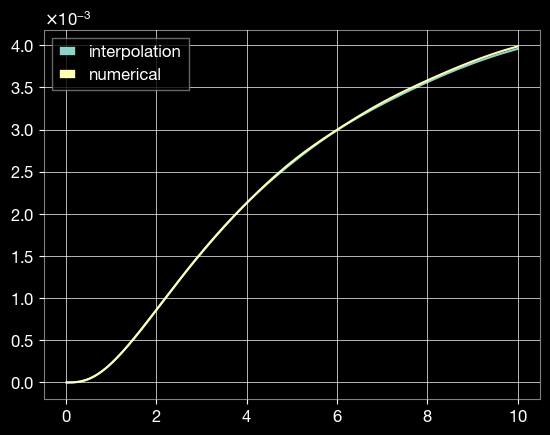

In [8]:
zs = np.linspace(0.01, 10., 1000)
tau_cs_int = ler_cs_int.optical_depth(zs)
tau_cs_num = ler_cs_num.optical_depth(zs)

plt.plot(zs, tau_cs_int, label='interpolation')
plt.plot(zs, tau_cs_num, label='numerical')
plt.legend()
plt.show()

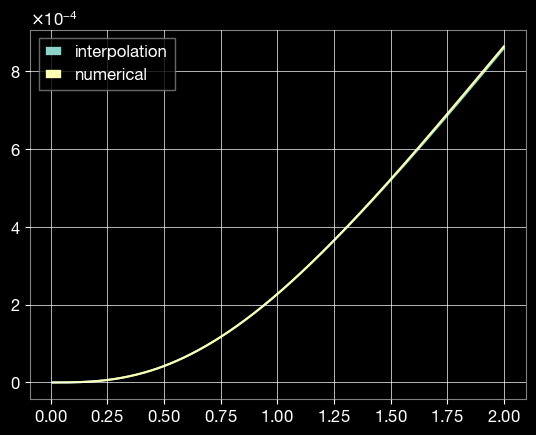

In [9]:
zs = np.linspace(0.01, 2., 1000)
tau_cs_int = ler_cs_int.optical_depth(zs)
tau_cs_num = ler_cs_num.optical_depth(zs)

plt.plot(zs, tau_cs_int, label='interpolation')
plt.plot(zs, tau_cs_num, label='numerical')
plt.legend()
plt.show()

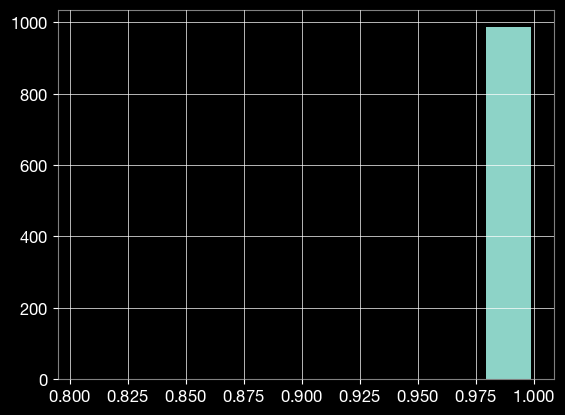

In [14]:
ratio =tau_cs_int/tau_cs_num
idx = np.isnan(ratio)
ratio = ratio[~idx]
plt.hist(ratio)
plt.show()

In [19]:
zs = np.linspace(0.01, 10., 1000)
tau_cs_int = ler_cs_int.optical_depth(zs)
tau_cs_num = ler_cs_num.optical_depth(zs)
relative_error =np.abs(tau_cs_int-tau_cs_num)/tau_cs_num
idx = np.isnan(relative_error)
relative_error_percent = relative_error[~idx]*100
# print min, max, mean, median, std
print(f"min: {np.min(relative_error_percent)}, max: {np.max(relative_error_percent)}, mean: {np.mean(relative_error_percent)}, median: {np.median(relative_error_percent)}, std: {np.std(relative_error_percent)}")


min: 0.0962036723581239, max: 8.125101560664023, mean: 0.46429755349153795, median: 0.4770976021060277, std: 0.2992262638183605
